# Final Project — GCN vs GAT on ogbn-arxiv

This notebook extends the PyG node-classification material from the laboratories to the `ogbn-arxiv` benchmark from OGB.

## Objectives

- build a strong full-batch `GCN` baseline
- implement a multi-head `GAT` model with attention extraction
- compare convergence, validation/test accuracy, parameter count, and training time
- analyze the learned representations and attention weights

## Notes

- The notebook uses the OGB split indices instead of `train_mask` / `val_mask` / `test_mask`.
- By default, the graph is converted to an undirected version, which is a common preprocessing choice for citation benchmarks.
- Expensive analyses such as t-SNE are sampled so they remain practical on CPU.

In [1]:
import copy
import json
import math
import os
import os.path as osp
import random
import time
from dataclasses import asdict, dataclass

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn.functional as F
from ogb.nodeproppred import Evaluator
from sklearn.manifold import TSNE
from sklearn.metrics import confusion_matrix
from torch.serialization import add_safe_globals
from torch_geometric.data.data import Data, DataEdgeAttr, DataTensorAttr
from torch_geometric.data.storage import BaseStorage, EdgeStorage, GlobalStorage, NodeStorage
from torch_geometric.loader import NeighborLoader
from torch_geometric.nn import GATConv, GATv2Conv, GCNConv, SAGEConv
from torch_geometric.transforms import Compose, NormalizeFeatures, ToUndirected
from torch_geometric.utils import degree, k_hop_subgraph

SEED = 42


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def register_pyg_safe_globals() -> None:
    add_safe_globals([Data, DataEdgeAttr, DataTensorAttr, BaseStorage, EdgeStorage, GlobalStorage, NodeStorage])


set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
print(f'Torch version: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')

sns.set_theme(style='whitegrid')

d:\Documents\FMI\Master Anul II\EDDL\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
Torch version: 2.11.0+cu128
CUDA available: True


## 1. Dataset Loading

The project uses the local `Proiect_Final/data` copy of `ogbn-arxiv` and keeps the official OGB evaluator.

The graph is converted to an undirected version by default. Feature normalization is disabled by default because the dataset already provides dense word2vec-style node embeddings, and row-wise normalization made the GAT model collapse to a single predicted class during debugging.

The graph object stays on CPU in this notebook. Full-batch baselines are moved to GPU inside the training utilities, while the attention models use `NeighborLoader` minibatches for training.

In [2]:
@dataclass
class DataConfig:
    root: str
    dataset_name: str = 'ogbn-arxiv'
    make_undirected: bool = True
    normalize_features: bool = False


class LocalOgbnArxivDataset:
    def __init__(self, root: str, transform=None):
        self.root = root
        self.name = 'ogbn-arxiv'
        self.transform = transform
        self.eval_metric = 'acc'
        self.num_tasks = 1

        data_obj, _ = torch.load(osp.join(root, 'processed', 'geometric_data_processed.pt'), weights_only=False)
        if self.transform is not None:
            data_obj = self.transform(data_obj)
        self._data = data_obj
        self.num_classes = int(self._data.y.max().item()) + 1

    @property
    def num_features(self) -> int:
        return int(self._data.x.size(-1))

    def __len__(self) -> int:
        return 1

    def __getitem__(self, idx: int):
        if idx != 0:
            raise IndexError('ogbn-arxiv contains a single graph object.')
        return self._data

    def _read_split(self, path: str) -> torch.Tensor:
        if osp.exists(path + '.gz'):
            values = pd.read_csv(path + '.gz', compression='gzip', header=None).values.T[0]
        else:
            values = pd.read_csv(path, header=None).values.T[0]
        values = np.asarray(values).copy()
        return torch.from_numpy(values).to(torch.long)

    def get_idx_split(self, split_type: str = 'time'):
        path = osp.join(self.root, 'split', split_type)
        return {
            'train': self._read_split(osp.join(path, 'train.csv')),
            'valid': self._read_split(osp.join(path, 'valid.csv')),
            'test': self._read_split(osp.join(path, 'test.csv')),
        }

    def __repr__(self) -> str:
        return f"LocalOgbnArxivDataset(root='{self.root}')"


def resolve_data_root() -> str:
    candidates = [
        osp.abspath('data'),
        osp.abspath(osp.join('Proiect_Final', 'data')),
    ]
    for candidate in candidates:
        if osp.exists(osp.join(candidate, 'processed', 'geometric_data_processed.pt')):
            return candidate
    raise FileNotFoundError('Could not locate the local ogbn-arxiv data folder.')


def build_transform(config: DataConfig):
    transforms = []
    if config.make_undirected:
        transforms.append(ToUndirected())
    if config.normalize_features:
        transforms.append(NormalizeFeatures())
    if not transforms:
        return None
    if len(transforms) == 1:
        return transforms[0]
    return Compose(transforms)


register_pyg_safe_globals()
config = DataConfig(root=resolve_data_root())
dataset = LocalOgbnArxivDataset(root=config.root, transform=build_transform(config))
data = dataset[0]
split_idx = dataset.get_idx_split()
evaluator = Evaluator(name=config.dataset_name)

print(dataset)
print(data)
print(f'Number of classes: {dataset.num_classes}')
print(f'Number of node features: {dataset.num_features}')
for split_name, index in split_idx.items():
    print(f'{split_name:>5} nodes: {index.numel()}')
print(f'Data root: {config.root}')
print(f'Make undirected: {config.make_undirected}')
print(f'Normalize features: {config.normalize_features}')
print(f'Data device after loading: {data.x.device}')

LocalOgbnArxivDataset(root='d:\Documents\FMI\Master Anul II\EDDL\Proiect_Final\data')
Data(num_nodes=169343, edge_index=[2, 2315598], x=[169343, 128], node_year=[169343, 1], y=[169343, 1])
Number of classes: 40
Number of node features: 128
train nodes: 90941
valid nodes: 29799
 test nodes: 48603
Data root: d:\Documents\FMI\Master Anul II\EDDL\Proiect_Final\data
Make undirected: True
Normalize features: False
Data device after loading: cpu


## 2. Models

The notebook now compares four architectures on the same train/validation/test split:

- `GCN` as the graph-convolution baseline
- `GraphSAGE` as an aggregation-based non-attention baseline
- `GAT` as the original attention model
- `GATv2` as the improved attention variant

For the attention-based models, the forward pass can optionally return:

- the penultimate embeddings for representation analysis
- attention weights from the final layer for visualization

In [3]:
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, dropout=0.5):
        super().__init__()
        if num_layers < 2:
            raise ValueError('num_layers must be at least 2')

        self.convs = torch.nn.ModuleList()
        self.convs.append(GCNConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
        self.convs.append(GCNConv(hidden_channels, out_channels))
        self.dropout = dropout

    def forward(self, x, edge_index, return_embeddings=False):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        embeddings = x
        logits = self.convs[-1](x, edge_index)

        if return_embeddings:
            return logits, embeddings
        return logits


class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, dropout=0.5):
        super().__init__()
        if num_layers < 2:
            raise ValueError('num_layers must be at least 2')

        self.convs = torch.nn.ModuleList()
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
        self.convs.append(SAGEConv(hidden_channels, out_channels))
        self.dropout = dropout

    def forward(self, x, edge_index, return_embeddings=False):
        for conv in self.convs[:-1]:
            x = conv(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)

        embeddings = x
        logits = self.convs[-1](x, edge_index)

        if return_embeddings:
            return logits, embeddings
        return logits


class AttentionModel(torch.nn.Module):
    conv_cls = None

    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, heads=8, dropout=0.6):
        super().__init__()
        if num_layers < 2:
            raise ValueError('num_layers must be at least 2')
        if self.conv_cls is None:
            raise ValueError('conv_cls must be set on subclasses')

        self.convs = torch.nn.ModuleList()
        self.convs.append(self.conv_cls(in_channels, hidden_channels, heads=heads, dropout=dropout))
        for _ in range(num_layers - 2):
            self.convs.append(self.conv_cls(hidden_channels * heads, hidden_channels, heads=heads, dropout=dropout))
        self.convs.append(self.conv_cls(hidden_channels * heads, out_channels, heads=1, concat=False, dropout=dropout))
        self.dropout = dropout

    def forward(self, x, edge_index, return_embeddings=False, return_attention=False):
        for conv in self.convs[:-1]:
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = conv(x, edge_index)
            x = F.elu(x)

        embeddings = x
        x = F.dropout(x, p=self.dropout, training=self.training)

        if return_attention:
            logits, attention = self.convs[-1](x, edge_index, return_attention_weights=True)
            if return_embeddings:
                return logits, embeddings, attention
            return logits, attention

        logits = self.convs[-1](x, edge_index)
        if return_embeddings:
            return logits, embeddings
        return logits


class GAT(AttentionModel):
    conv_cls = GATConv


class GATv2(AttentionModel):
    conv_cls = GATv2Conv


def count_parameters(model: torch.nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

## 3. Training and Evaluation Utilities

Both models use the same training loop and the same validation-based model selection strategy. This keeps the comparison fair and reproduces the pattern already used in the labs, adapted to OGB split indices.

In [4]:
@dataclass
class ExperimentConfig:
    hidden_channels: int = 64
    num_layers: int = 2
    dropout: float = 0.5
    heads: int = 8
    lr: float = 0.005
    weight_decay: float = 5e-4
    epochs: int = 200
    log_every: int = 10
    eval_every: int = 1
    debug_predictions: bool = False
    training_mode: str = 'full_batch'
    train_batch_size: int = 1024
    eval_batch_size: int = 4096
    train_num_neighbors: tuple = (-1, -1)
    eval_num_neighbors: tuple | None = None


MODEL_NAME_ALIASES = {
    'gcn': 'GCN',
    'graphsage': 'GraphSAGE',
    'sage': 'GraphSAGE',
    'gat': 'GAT',
    'gatv2': 'GATv2',
}


def canonical_model_name(model_name: str) -> str:
    key = model_name.replace('-', '').replace('_', '').lower()
    return MODEL_NAME_ALIASES.get(key, model_name)


def artifact_base_name(model_name: str) -> str:
    return canonical_model_name(model_name).lower().replace('-', '').replace('_', '')


def prediction_stats(pred, index):
    subset_pred = pred[index].view(-1)
    values, counts = torch.unique(subset_pred, return_counts=True)
    top = torch.argmax(counts)
    return {
        'unique_predictions': int(values.numel()),
        'top_class': int(values[top]),
        'top_share': float(counts[top] / subset_pred.numel()),
    }


def get_model_device(model):
    return next(model.parameters()).device


def cpu_state_dict(model):
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }


def ensure_cpu_sampling_inputs(data, split_idx):
    data_cpu = data.cpu()
    split_idx_cpu = {
        key: value.cpu()
        for key, value in split_idx.items()
    }
    return data_cpu, split_idx_cpu


def get_artifact_dir() -> str:
    path = osp.abspath(osp.join('Proiect_Final', 'artifacts'))
    os.makedirs(path, exist_ok=True)
    return path


def get_artifact_paths(model_name: str):
    artifact_dir = get_artifact_dir()
    base_name = artifact_base_name(model_name)
    return {
        'checkpoint_path': osp.join(artifact_dir, f'{base_name}_best.pt'),
        'history_path': osp.join(artifact_dir, f'{base_name}_history.json'),
        'prediction_path': osp.join(artifact_dir, f'{base_name}_test_pred.pt'),
    }


def serialize_config(config: ExperimentConfig) -> dict:
    config_dict = asdict(config)
    config_dict['train_num_neighbors'] = list(config.train_num_neighbors)
    if config.eval_num_neighbors is not None:
        config_dict['eval_num_neighbors'] = list(config.eval_num_neighbors)
    return config_dict


def deserialize_config(config_dict: dict) -> ExperimentConfig:
    payload = copy.deepcopy(config_dict)
    payload['train_num_neighbors'] = tuple(payload['train_num_neighbors'])
    if payload.get('eval_num_neighbors') is not None:
        payload['eval_num_neighbors'] = tuple(payload['eval_num_neighbors'])
    return ExperimentConfig(**payload)


def read_json(path: str) -> dict:
    with open(path, 'r', encoding='utf-8') as handle:
        return json.load(handle)


def save_experiment_artifacts(model_name, best_state_dict, history, result_summary, best_pred, config):
    artifact_paths = get_artifact_paths(model_name)

    torch.save(best_state_dict, artifact_paths['checkpoint_path'])
    torch.save(best_pred, artifact_paths['prediction_path'])
    with open(artifact_paths['history_path'], 'w', encoding='utf-8') as handle:
        json.dump(
            {
                'summary': result_summary,
                'history': history,
                'config': serialize_config(config),
            },
            handle,
            indent=2,
        )

    return artifact_paths


def get_default_config_for_model(model_name: str) -> ExperimentConfig:
    config_by_model = {
        'GCN': globals().get('gcn_config'),
        'GraphSAGE': globals().get('sage_config'),
        'GAT': globals().get('gat_config'),
        'GATv2': globals().get('gatv2_config'),
    }
    config = config_by_model.get(canonical_model_name(model_name))
    if config is None:
        raise ValueError(f'No config is available for model {model_name}. Run the configuration cell first.')
    return copy.deepcopy(config)


def get_model_class(model_name: str):
    class_by_model = {
        'GCN': GCN,
        'GraphSAGE': GraphSAGE,
        'GAT': GAT,
        'GATv2': GATv2,
    }
    canonical_name = canonical_model_name(model_name)
    if canonical_name not in class_by_model:
        raise ValueError(f'Unknown model name: {model_name}')
    return class_by_model[canonical_name]


def build_model_from_config(model_name: str, config: ExperimentConfig):
    canonical_name = canonical_model_name(model_name)
    common_kwargs = {
        'in_channels': dataset.num_features,
        'hidden_channels': config.hidden_channels,
        'out_channels': dataset.num_classes,
        'num_layers': config.num_layers,
        'dropout': config.dropout,
    }

    if canonical_name in {'GAT', 'GATv2'}:
        return get_model_class(canonical_name)(heads=config.heads, **common_kwargs)
    return get_model_class(canonical_name)(**common_kwargs)


def list_saved_model_names():
    artifact_dir = get_artifact_dir()
    saved_names = []
    for file_name in os.listdir(artifact_dir):
        if not file_name.endswith('_history.json'):
            continue
        base_name = file_name[:-len('_history.json')]
        saved_names.append(canonical_model_name(base_name))

    ordered_names = []
    for model_name in ('GCN', 'GraphSAGE', 'GAT', 'GATv2'):
        if model_name in saved_names:
            ordered_names.append(model_name)
    return ordered_names


def load_saved_result(model_name: str, load_model: bool = False):
    canonical_name = canonical_model_name(model_name)
    artifact_paths = get_artifact_paths(canonical_name)
    history_payload = read_json(artifact_paths['history_path'])
    summary = history_payload.get('summary', {})
    history = history_payload.get('history', {})
    config_payload = history_payload.get('config')
    pred = torch.load(artifact_paths['prediction_path'], map_location='cpu', weights_only=False)

    result = {
        'model_name': summary.get('model_name', canonical_name),
        'history': history,
        'best_epoch': summary.get('best_epoch'),
        'best_val_acc': summary.get('best_val_acc'),
        'best_test_acc': summary.get('best_test_acc'),
        'pred': pred,
        'train_time_sec': summary.get('train_time_sec'),
        'parameter_count': summary.get('parameter_count'),
        'training_mode': summary.get('training_mode'),
        'eval_every': summary.get('eval_every'),
        'model_load_error': None,
        **artifact_paths,
    }

    config = deserialize_config(config_payload) if config_payload is not None else get_default_config_for_model(canonical_name)
    result['config'] = config
    result['model'] = None

    if load_model:
        model = build_model_from_config(canonical_name, config)
        state_dict = torch.load(artifact_paths['checkpoint_path'], map_location='cpu', weights_only=False)
        try:
            model.load_state_dict(state_dict)
        except RuntimeError as exc:
            result['model_load_error'] = str(exc)
        else:
            model.eval()
            result['model'] = model

    return result


def load_saved_results(model_names=None, load_models: bool = False):
    if model_names is None:
        model_names = list_saved_model_names()

    loaded_results = {}
    for model_name in model_names:
        try:
            result = load_saved_result(model_name, load_model=load_models)
        except FileNotFoundError:
            continue
        loaded_results[result['model_name']] = result
    return loaded_results


def validate_sampling_config(model, config):
    if config.training_mode not in {'full_batch', 'neighbor_loader'}:
        raise ValueError("training_mode must be 'full_batch' or 'neighbor_loader'.")
    if config.eval_every < 1:
        raise ValueError('eval_every must be at least 1.')

    if config.training_mode == 'neighbor_loader':
        num_layers = len(model.convs)
        if len(config.train_num_neighbors) != num_layers:
            raise ValueError('train_num_neighbors must match the number of GNN layers.')
        eval_num_neighbors = config.eval_num_neighbors or tuple([-1] * num_layers)
        if len(eval_num_neighbors) != num_layers:
            raise ValueError('eval_num_neighbors must match the number of GNN layers.')


def build_neighbor_loader(data, input_nodes, num_neighbors, batch_size, shuffle):
    return NeighborLoader(
        data,
        input_nodes=input_nodes,
        num_neighbors=list(num_neighbors),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
    )


def train_epoch_full_batch(model, data, optimizer, split_idx):
    model.train()
    optimizer.zero_grad()
    logits = model(data.x, data.edge_index)
    loss = F.cross_entropy(logits[split_idx['train']], data.y[split_idx['train']].view(-1))
    loss.backward()
    optimizer.step()
    return float(loss.item())


def train_epoch_neighbor_loader(model, data, optimizer, split_idx, config):
    model.train()
    loader = build_neighbor_loader(
        data=data,
        input_nodes=split_idx['train'],
        num_neighbors=config.train_num_neighbors,
        batch_size=config.train_batch_size,
        shuffle=True,
    )

    total_loss = 0.0
    total_examples = 0
    num_steps = 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        logits = model(batch.x, batch.edge_index)
        loss = F.cross_entropy(logits[:batch.batch_size], batch.y[:batch.batch_size].view(-1))
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * batch.batch_size
        total_examples += int(batch.batch_size)
        num_steps += 1

    return total_loss / max(total_examples, 1), num_steps


@torch.no_grad()
def predict_full_batch(model, data):
    model.eval()
    logits = model(data.x, data.edge_index)
    return logits.detach().cpu()


@torch.no_grad()
def predict_with_neighbor_loader(model, data, config):
    model.eval()
    eval_num_neighbors = config.eval_num_neighbors or tuple([-1] * len(model.convs))
    loader = build_neighbor_loader(
        data=data,
        input_nodes=torch.arange(data.num_nodes),
        num_neighbors=eval_num_neighbors,
        batch_size=config.eval_batch_size,
        shuffle=False,
    )

    logits_all = None

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index)[:batch.batch_size].detach().cpu()
        seed_nodes = batch.n_id[:batch.batch_size].detach().cpu()
        if logits_all is None:
            logits_all = torch.empty((data.num_nodes, logits.size(-1)), dtype=logits.dtype)
        logits_all[seed_nodes] = logits

    return logits_all


@torch.no_grad()
def evaluate(model, data, split_idx, evaluator, config, full_batch_data=None):
    if config.training_mode == 'neighbor_loader':
        logits = predict_with_neighbor_loader(model, data, config)
    else:
        if full_batch_data is None:
            raise ValueError('full_batch_data is required for full-batch evaluation.')
        logits = predict_full_batch(model, full_batch_data)

    pred = logits.argmax(dim=-1, keepdim=True)

    scores = {}
    for split_name in ('train', 'valid', 'test'):
        scores[split_name] = evaluator.eval({
            'y_true': data.y[split_idx[split_name]],
            'y_pred': pred[split_idx[split_name]],
        })['acc']
    return scores, pred


@torch.no_grad()
def export_embeddings(model, data):
    model_device = get_model_device(model)
    data_for_export = data.to(model_device)

    model.eval()
    _, embeddings = model(data_for_export.x, data_for_export.edge_index, return_embeddings=True)
    embeddings = embeddings.detach().cpu()

    if model_device.type == 'cuda':
        torch.cuda.empty_cache()

    return embeddings


@torch.no_grad()
def export_attention(model, data):
    if not isinstance(model, (GAT, GATv2)):
        raise TypeError('Attention weights are only available for GAT and GATv2 models.')

    model_device = get_model_device(model)
    data_for_export = data.to(model_device)

    model.eval()
    _, embeddings, attention = model(
        data_for_export.x,
        data_for_export.edge_index,
        return_embeddings=True,
        return_attention=True,
    )
    edge_index_att, alpha = attention
    embeddings = embeddings.detach().cpu()
    attention = (edge_index_att.detach().cpu(), alpha.detach().cpu())

    if model_device.type == 'cuda':
        torch.cuda.empty_cache()

    return embeddings, attention


def run_experiment(model_name, model, data, split_idx, evaluator, config):
    validate_sampling_config(model, config)
    optimizer = torch.optim.Adam(model.parameters(), lr=config.lr, weight_decay=config.weight_decay)

    history = {'loss': [], 'train': [], 'valid': [], 'test': []}
    best = {
        'val_acc': 0.0,
        'test_acc': 0.0,
        'epoch': 0,
        'state_dict': None,
        'pred': None,
    }

    full_batch_data = None
    full_batch_split_idx = None
    sampling_data = None
    sampling_split_idx = None

    if config.training_mode == 'full_batch':
        full_batch_data = data.to(device)
        full_batch_split_idx = {key: value.to(device) for key, value in split_idx.items()}
    else:
        sampling_data, sampling_split_idx = ensure_cpu_sampling_inputs(data, split_idx)

    start_time = time.perf_counter()

    for epoch in range(1, config.epochs + 1):
        if config.training_mode == 'neighbor_loader':
            loss, num_steps = train_epoch_neighbor_loader(model, sampling_data, optimizer, sampling_split_idx, config)
        else:
            loss = train_epoch_full_batch(model, full_batch_data, optimizer, full_batch_split_idx)
            num_steps = 1

        should_evaluate = epoch == 1 or epoch % config.eval_every == 0 or epoch == config.epochs
        scores = None
        pred = None

        if should_evaluate:
            scores, pred = evaluate(
                model,
                sampling_data if config.training_mode == 'neighbor_loader' else data,
                sampling_split_idx if config.training_mode == 'neighbor_loader' else split_idx,
                evaluator,
                config,
                full_batch_data,
            )

            history['train'].append(scores['train'])
            history['valid'].append(scores['valid'])
            history['test'].append(scores['test'])

            if best['state_dict'] is None or scores['valid'] > best['val_acc']:
                best['val_acc'] = scores['valid']
                best['test_acc'] = scores['test']
                best['epoch'] = epoch
                best['state_dict'] = cpu_state_dict(model)
                best['pred'] = pred.detach().cpu()
        else:
            history['train'].append(math.nan)
            history['valid'].append(math.nan)
            history['test'].append(math.nan)

        history['loss'].append(loss)

        should_log = epoch == 1 or epoch % config.log_every == 0 or epoch == config.epochs
        if should_log:
            if should_evaluate:
                message = (
                    f"{model_name:>10} | Epoch {epoch:03d} | Mode {config.training_mode:<15} | Steps {num_steps:03d} | "
                    f"Loss {loss:.4f} | Train {scores['train']:.4f} | Valid {scores['valid']:.4f} | Test {scores['test']:.4f}"
                )
                if config.debug_predictions:
                    stats = prediction_stats(
                        pred,
                        sampling_split_idx['train'] if config.training_mode == 'neighbor_loader' else split_idx['train'],
                    )
                    message += (
                        f" | UniquePred {stats['unique_predictions']:02d}"
                        f" | TopClass {stats['top_class']:02d}"
                        f" | TopShare {stats['top_share']:.4f}"
                    )
            else:
                message = (
                    f"{model_name:>10} | Epoch {epoch:03d} | Mode {config.training_mode:<15} | Steps {num_steps:03d} | "
                    f"Loss {loss:.4f} | Eval deferred to every {config.eval_every} epochs"
                )
            print(message)

    elapsed = time.perf_counter() - start_time
    model.load_state_dict(best['state_dict'])
    model = model.to('cpu')
    del optimizer
    del full_batch_data
    del full_batch_split_idx
    del sampling_data
    del sampling_split_idx

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    summary = {
        'model_name': model_name,
        'best_epoch': best['epoch'],
        'best_val_acc': best['val_acc'],
        'best_test_acc': best['test_acc'],
        'train_time_sec': elapsed,
        'parameter_count': count_parameters(model),
        'training_mode': config.training_mode,
        'eval_every': config.eval_every,
    }
    artifact_paths = save_experiment_artifacts(
        model_name=model_name,
        best_state_dict=best['state_dict'],
        history=history,
        result_summary=summary,
        best_pred=best['pred'],
        config=config,
    )

    result = {
        'model_name': model_name,
        'history': history,
        'best_epoch': best['epoch'],
        'best_val_acc': best['val_acc'],
        'best_test_acc': best['test_acc'],
        'pred': best['pred'],
        'train_time_sec': elapsed,
        'parameter_count': count_parameters(model),
        'training_mode': config.training_mode,
        'eval_every': config.eval_every,
        'config': copy.deepcopy(config),
        'model': model,
        'model_load_error': None,
        **artifact_paths,
    }

    return result

## 4. Visualization Utilities

The functions below are designed so you can rerun analysis without retraining the models. The heavier operations sample from the test set to keep CPU runtime reasonable.

In [ ]:
def plot_training_curves(results):
    fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5), sharey=True)
    if len(results) == 1:
        axes = [axes]

    for axis, (name, result) in zip(axes, results.items()):
        history = result['history']
        axis.plot(history['train'], label='Train')
        axis.plot(history['valid'], label='Validation')
        axis.plot(history['test'], label='Test')
        axis.set_title(f'{name} Accuracy over Epochs')
        axis.set_xlabel('Epoch')
        axis.set_ylabel('Accuracy')
        axis.legend()

    plt.tight_layout()


def plot_loss_curves(results):
    plt.figure(figsize=(10, 5))
    for name, result in results.items():
        plt.plot(result['history']['loss'], label=f'{name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross-Entropy Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.tight_layout()


def build_summary_rows(results, target_val_acc=0.60):
    rows = []
    for name, result in results.items():
        valid_history = np.array(result['history']['valid'])
        reached = np.flatnonzero(valid_history >= target_val_acc)
        epochs_to_target = int(reached[0] + 1) if reached.size else None
        rows.append({
            'Model': name,
            'Validation Accuracy': round(result['best_val_acc'], 4),
            'Test Accuracy': round(result['best_test_acc'], 4),
            'Parameters': result['parameter_count'],
            'Training Time (s)': round(result['train_time_sec'], 2),
            f'Epochs to {target_val_acc:.0%} Val Acc': epochs_to_target,
            'Best Epoch': result['best_epoch'],
        })
    return rows


def print_summary_table(rows):
    headers = list(rows[0].keys())
    widths = []
    for header in headers:
        max_width = max(len(str(row[header])) for row in rows)
        widths.append(max(max_width, len(header)))

    header_line = ' | '.join(header.ljust(width) for header, width in zip(headers, widths))
    divider = '-+-'.join('-' * width for width in widths)
    print(header_line)
    print(divider)
    for row in rows:
        print(' | '.join(str(row[header]).ljust(width) for header, width in zip(headers, widths)))


def plot_confusion_matrices(y_true, predictions):
    fig, axes = plt.subplots(1, len(predictions), figsize=(9 * len(predictions), 7))
    if len(predictions) == 1:
        axes = [axes]

    for axis, (name, pred) in zip(axes, predictions.items()):
        cm = confusion_matrix(y_true, pred)
        sns.heatmap(cm, ax=axis, cmap='Blues', xticklabels=False, yticklabels=False)
        axis.set_title(f'{name} Confusion Matrix')
        axis.set_xlabel('Predicted')
        axis.set_ylabel('True')

    plt.tight_layout()


def compute_per_class_accuracy(y_true, pred, num_classes):
    values = []
    for class_idx in range(num_classes):
        mask = y_true == class_idx
        if mask.sum() == 0:
            values.append(float('nan'))
            continue
        values.append(float((pred[mask] == class_idx).mean()))
    return values


def plot_per_class_accuracy(per_class_scores):
    plt.figure(figsize=(14, 6))
    x = np.arange(len(next(iter(per_class_scores.values()))))
    width = 0.4
    offsets = np.linspace(-width / 2, width / 2, len(per_class_scores))

    for offset, (name, scores) in zip(offsets, per_class_scores.items()):
        plt.bar(x + offset, scores, width=width / max(len(per_class_scores), 1), alpha=0.7, label=name)

    plt.xlabel('Class')
    plt.ylabel('Accuracy')
    plt.title('Per-Class Accuracy')
    plt.legend()
    plt.tight_layout()


def plot_degree_vs_accuracy(data, split_idx, pred, title):
    deg = degree(data.edge_index[0], num_nodes=data.num_nodes).cpu().numpy()
    test_deg = deg[split_idx['test'].cpu().numpy()]
    test_truth = data.y[split_idx['test']].view(-1).cpu().numpy()
    correct = pred == test_truth

    plt.figure(figsize=(10, 5))
    plt.scatter(test_deg, correct.astype(float), alpha=0.05, s=5)
    plt.xlabel('Node Degree')
    plt.ylabel('Correct (1) / Wrong (0)')
    plt.title(title)

    bins = np.linspace(0, max(test_deg.max(), 1), 50)
    means = []
    centers = []
    for left, right in zip(bins[:-1], bins[1:]):
        mask = (test_deg >= left) & (test_deg < right)
        if mask.any():
            means.append(correct[mask].mean())
            centers.append((left + right) / 2)
    if centers:
        plt.plot(centers, means, color='red', label='Running mean')
        plt.legend()
    plt.tight_layout()


def compute_edge_homophily(data):
    src, dst = data.edge_index
    labels = data.y.view(-1)
    valid_mask = (labels[src] >= 0) & (labels[dst] >= 0)
    if not bool(valid_mask.any()):
        return float('nan')
    return float((labels[src[valid_mask]] == labels[dst[valid_mask]]).float().mean().item())


def plot_label_homophily_subgraph(data, node_idx, num_hops=1, max_nodes=25, title=None):
    subset, sub_edge_index, mapping, _ = k_hop_subgraph(
        node_idx=node_idx,
        num_hops=num_hops,
        edge_index=data.edge_index,
        relabel_nodes=True,
    )

    if subset.numel() > max_nodes:
        center = int(mapping.item())
        distances = torch.cdist(
            torch.arange(subset.numel(), dtype=torch.float32).unsqueeze(1),
            torch.tensor([[center]], dtype=torch.float32),
        ).view(-1)
        keep = torch.argsort(distances)[:max_nodes]
        keep = torch.sort(keep).values
        keep_mask = torch.zeros(subset.numel(), dtype=torch.bool)
        keep_mask[keep] = True
        edge_keep = keep_mask[sub_edge_index[0]] & keep_mask[sub_edge_index[1]]
        sub_edge_index = sub_edge_index[:, edge_keep]
        old_to_new = -torch.ones(subset.numel(), dtype=torch.long)
        old_to_new[keep] = torch.arange(keep.numel())
        sub_edge_index = old_to_new[sub_edge_index]
        subset = subset[keep]
        mapping = old_to_new[mapping]

    node_labels = data.y[subset].view(-1).detach().cpu().numpy()
    edge_sources = sub_edge_index[0].detach().cpu().numpy()
    edge_targets = sub_edge_index[1].detach().cpu().numpy()
    same_label_mask = node_labels[edge_sources] == node_labels[edge_targets]

    graph = nx.DiGraph()
    graph.add_nodes_from(range(subset.numel()))
    graph.add_edges_from(sub_edge_index.t().detach().cpu().tolist())

    pos = nx.spring_layout(graph, seed=SEED)
    cmap = plt.cm.get_cmap('tab20', dataset.num_classes)
    node_colors = [cmap(int(label) % dataset.num_classes) for label in node_labels]
    edge_colors = ['tab:green' if same else 'lightgray' for same in same_label_mask]
    edge_widths = [2.4 if same else 1.2 for same in same_label_mask]

    plt.figure(figsize=(8, 6))
    nx.draw_networkx_nodes(graph, pos, node_color=node_colors, node_size=320, edgecolors='black', linewidths=0.5)
    nx.draw_networkx_edges(
        graph,
        pos,
        edge_color=edge_colors,
        width=edge_widths,
        arrows=True,
        arrowstyle='-|>',
        arrowsize=12,
        alpha=0.85,
    )
    nx.draw_networkx_labels(
        graph,
        pos,
        labels={idx: f'{idx}\n(c{int(label)})' for idx, label in enumerate(node_labels)},
        font_size=8,
    )

    center_node = int(mapping.item())
    nx.draw_networkx_nodes(
        graph,
        pos,
        nodelist=[center_node],
        node_color=[node_colors[center_node]],
        node_size=420,
        edgecolors='crimson',
        linewidths=2.0,
    )

    local_homophily = float(same_label_mask.mean()) if same_label_mask.size else float('nan')
    if title is None:
        title = (
            f'Label-colored {num_hops}-hop subgraph around node {node_idx} '
            f'| local edge homophily={local_homophily:.3f}'
        )
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()

    return {
        'subset': subset,
        'sub_edge_index': sub_edge_index,
        'node_labels': node_labels,
        'local_edge_homophily': local_homophily,
        'center_node': center_node,
    }


def plot_attention_distribution(alpha, title='Distribution of Attention Weights per Head'):
    alpha_np = alpha.detach().cpu().numpy()
    plt.figure(figsize=(10, 5))
    for head_idx in range(alpha_np.shape[1]):
        sns.kdeplot(alpha_np[:, head_idx], label=f'Head {head_idx}')
    plt.xlabel('Attention weight')
    plt.ylabel('Density')
    plt.title(title)
    plt.legend()
    plt.tight_layout()


def plot_attention_subgraph(edge_index_att, alpha, node_idx, num_hops=1, head_idx=0, max_edges=80, title=None):
    subset, sub_edge_index, mapping, edge_mask = k_hop_subgraph(
        node_idx=node_idx,
        num_hops=num_hops,
        edge_index=edge_index_att,
        relabel_nodes=True,
    )
    sub_alpha = alpha[edge_mask, head_idx].detach().cpu().numpy()

    if sub_edge_index.size(1) > max_edges:
        keep = np.argsort(-sub_alpha)[:max_edges]
        sub_edge_index = sub_edge_index[:, keep]
        sub_alpha = sub_alpha[keep]

    graph = nx.DiGraph()
    graph.add_nodes_from(range(subset.numel()))
    graph.add_edges_from(sub_edge_index.t().detach().cpu().tolist())

    pos = nx.spring_layout(graph, seed=SEED)
    plt.figure(figsize=(8, 6))
    nx.draw_networkx_nodes(graph, pos, node_color='lightblue', node_size=250)
    nx.draw_networkx_edges(graph, pos, edge_color=sub_alpha, edge_cmap=plt.cm.Reds, width=2)
    nx.draw_networkx_labels(graph, pos, font_size=8)
    if title is None:
        title = f'Attention on {num_hops}-hop subgraph around node {node_idx} (head {head_idx})'
    plt.title(title)
    plt.axis('off')
    plt.tight_layout()


def plot_tsne_comparison(raw_features, learned_embeddings, labels, sample_size=3000, perplexity=40, title_suffix=''):
    sample_size = min(sample_size, raw_features.size(0))
    generator = torch.Generator().manual_seed(SEED)
    indices = torch.randperm(raw_features.size(0), generator=generator)[:sample_size]

    raw_np = raw_features[indices].detach().cpu().numpy()
    emb_np = learned_embeddings[indices].detach().cpu().numpy()
    label_np = labels[indices].detach().cpu().numpy().reshape(-1)

    raw_2d = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(raw_np)
    emb_2d = TSNE(n_components=2, random_state=SEED, perplexity=perplexity).fit_transform(emb_np)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    axes[0].scatter(raw_2d[:, 0], raw_2d[:, 1], c=label_np, cmap='tab20', s=6, alpha=0.65)
    axes[0].set_title('Raw Features t-SNE')
    axes[1].scatter(emb_2d[:, 0], emb_2d[:, 1], c=label_np, cmap='tab20', s=6, alpha=0.65)
    axes[1].set_title(f'Learned Embeddings t-SNE{title_suffix}')
    for axis in axes:
        axis.set_xticks([])
        axis.set_yticks([])
    plt.tight_layout()


def ensure_results_loaded(load_models=False, model_names=None):
    global results
    if not results:
        results = load_saved_results(model_names=model_names, load_models=load_models)
        return results

    if load_models:
        missing_models = [
            model_name
            for model_name in (model_names or results.keys())
            if model_name not in results or results[model_name].get('model') is None
        ]
        if missing_models:
            results.update(load_saved_results(model_names=missing_models, load_models=True))
    return results


def collect_model_embeddings(model_names, data):
    ensure_results_loaded(load_models=True, model_names=model_names)
    embeddings = {}
    for model_name in model_names:
        result = results.get(model_name)
        if result is None:
            continue
        if result.get('model') is None:
            if result.get('model_load_error'):
                print(f"Skipping embeddings for {model_name}: {result['model_load_error']}")
            continue
        embeddings[model_name] = export_embeddings(result['model'], data)
    return embeddings

## 5. Run Experiments

The next cells use a mixed protocol:

- `GCN` and `GraphSAGE` train in full-batch mode.
- `GAT` and `GATv2` train with `NeighborLoader` minibatches.
- Validation and test accuracy are computed less frequently than the training loss for the attention models because the full-graph evaluation pass is the main runtime bottleneck.

The attention-based models print prediction-diversity diagnostics on the training split whenever an evaluation pass runs. If `UniquePred` stays at `1` and `TopShare` stays near `1.0`, the model is still collapsed to a single predicted class.

Each finished model and its best checkpoint are moved back to CPU after training. The best checkpoint, prediction tensor, and metric history are also saved automatically under `Proiect_Final/artifacts`.

`GATv2` remains more memory-hungry than `GAT`, so it still uses a smaller default configuration than the baselines.

In [6]:
gcn_config = ExperimentConfig(
    hidden_channels=128,
    num_layers=2,
    dropout=0.5,
    lr=0.01,
    weight_decay=5e-4,
    epochs=200,
    log_every=10,
    training_mode='full_batch',
)

sage_config = ExperimentConfig(
    hidden_channels=128,
    num_layers=2,
    dropout=0.5,
    lr=0.01,
    weight_decay=5e-4,
    epochs=200,
    log_every=10,
    training_mode='full_batch',
)

gat_config = ExperimentConfig(
    hidden_channels=32,
    num_layers=2,
    dropout=0.5,
    heads=4,
    lr=0.005,
    weight_decay=5e-4,
    epochs=200,
    log_every=10,
    debug_predictions=True,
    training_mode='full_batch',
    train_batch_size=1024,
    eval_batch_size=4096,
    train_num_neighbors=(15, 10),
    eval_num_neighbors=(-1, -1),
    eval_every=10,
)

gatv2_config = ExperimentConfig(
    hidden_channels=32,
    num_layers=2,
    dropout=0.4,
    heads=4,
    lr=0.003,
    weight_decay=5e-4,
    epochs=200,
    log_every=10,
    debug_predictions=True,
    training_mode='full_batch',
    train_batch_size=1024,
    eval_batch_size=4096,
    train_num_neighbors=(15, 10),
    eval_num_neighbors=(-1, -1),
    eval_every=10,
)

results = {}

In [7]:
gcn_model = GCN(
    in_channels=dataset.num_features,
    hidden_channels=gcn_config.hidden_channels,
    out_channels=dataset.num_classes,
    num_layers=gcn_config.num_layers,
    dropout=gcn_config.dropout,
).to(device)

results['GCN'] = run_experiment(
    model_name='GCN',
    model=gcn_model,
    data=data,
    split_idx=split_idx,
    evaluator=evaluator,
    config=gcn_config,
)

sage_model = GraphSAGE(
    in_channels=dataset.num_features,
    hidden_channels=sage_config.hidden_channels,
    out_channels=dataset.num_classes,
    num_layers=sage_config.num_layers,
    dropout=sage_config.dropout,
).to(device)

results['GraphSAGE'] = run_experiment(
    model_name='GraphSAGE',
    model=sage_model,
    data=data,
    split_idx=split_idx,
    evaluator=evaluator,
    config=sage_config,
)

       GCN | Epoch 001 | Mode full_batch      | Steps 001 | Loss 3.7295 | Train 0.2538 | Valid 0.2725 | Test 0.2477
       GCN | Epoch 010 | Mode full_batch      | Steps 001 | Loss 2.8538 | Train 0.2768 | Valid 0.2962 | Test 0.2676
       GCN | Epoch 020 | Mode full_batch      | Steps 001 | Loss 2.3204 | Train 0.4402 | Valid 0.4371 | Test 0.4159
       GCN | Epoch 030 | Mode full_batch      | Steps 001 | Loss 1.8845 | Train 0.5278 | Valid 0.5396 | Test 0.5286
       GCN | Epoch 040 | Mode full_batch      | Steps 001 | Loss 1.6210 | Train 0.5813 | Valid 0.5953 | Test 0.5831
       GCN | Epoch 050 | Mode full_batch      | Steps 001 | Loss 1.4596 | Train 0.6130 | Valid 0.6259 | Test 0.6184
       GCN | Epoch 060 | Mode full_batch      | Steps 001 | Loss 1.3745 | Train 0.6295 | Valid 0.6394 | Test 0.6277
       GCN | Epoch 070 | Mode full_batch      | Steps 001 | Loss 1.3260 | Train 0.6406 | Valid 0.6525 | Test 0.6449
       GCN | Epoch 080 | Mode full_batch      | Steps 001 | Loss 1.2946 

In [8]:
gat_model = GAT(
    in_channels=dataset.num_features,
    hidden_channels=gat_config.hidden_channels,
    out_channels=dataset.num_classes,
    num_layers=gat_config.num_layers,
    heads=gat_config.heads,
    dropout=gat_config.dropout,
).to(device)

results['GAT'] = run_experiment(
    model_name='GAT',
    model=gat_model,
    data=data,
    split_idx=split_idx,
    evaluator=evaluator,
    config=gat_config,
)

       GAT | Epoch 001 | Mode full_batch      | Steps 001 | Loss 3.7572 | Train 0.1905 | Valid 0.1048 | Test 0.0840 | UniquePred 10 | TopClass 28 | TopShare 0.8767
       GAT | Epoch 010 | Mode full_batch      | Steps 001 | Loss 2.9139 | Train 0.2943 | Valid 0.3075 | Test 0.2753 | UniquePred 08 | TopClass 28 | TopShare 0.6979
       GAT | Epoch 020 | Mode full_batch      | Steps 001 | Loss 2.5285 | Train 0.4252 | Valid 0.4415 | Test 0.4296 | UniquePred 11 | TopClass 28 | TopShare 0.3430
       GAT | Epoch 030 | Mode full_batch      | Steps 001 | Loss 2.2138 | Train 0.5275 | Valid 0.5532 | Test 0.5528 | UniquePred 19 | TopClass 28 | TopShare 0.2472
       GAT | Epoch 040 | Mode full_batch      | Steps 001 | Loss 2.0408 | Train 0.5642 | Valid 0.5841 | Test 0.5792 | UniquePred 24 | TopClass 28 | TopShare 0.2148
       GAT | Epoch 050 | Mode full_batch      | Steps 001 | Loss 1.9226 | Train 0.5884 | Valid 0.6039 | Test 0.5949 | UniquePred 24 | TopClass 28 | TopShare 0.2072
       GAT | Epo

In [9]:
gatv2_model = GATv2(
    in_channels=dataset.num_features,
    hidden_channels=gatv2_config.hidden_channels,
    out_channels=dataset.num_classes,
    num_layers=gatv2_config.num_layers,
    heads=gatv2_config.heads,
    dropout=gatv2_config.dropout,
).to(device)

results['GATv2'] = run_experiment(
    model_name='GATv2',
    model=gatv2_model,
    data=data,
    split_idx=split_idx,
    evaluator=evaluator,
    config=gatv2_config,
)

     GATv2 | Epoch 001 | Mode full_batch      | Steps 001 | Loss 3.7590 | Train 0.1625 | Valid 0.0689 | Test 0.0545 | UniquePred 11 | TopClass 28 | TopShare 0.9492
     GATv2 | Epoch 010 | Mode full_batch      | Steps 001 | Loss 3.0305 | Train 0.2842 | Valid 0.3040 | Test 0.2728 | UniquePred 06 | TopClass 28 | TopShare 0.6413
     GATv2 | Epoch 020 | Mode full_batch      | Steps 001 | Loss 2.7619 | Train 0.3028 | Valid 0.3119 | Test 0.2795 | UniquePred 10 | TopClass 28 | TopShare 0.5606
     GATv2 | Epoch 030 | Mode full_batch      | Steps 001 | Loss 2.4894 | Train 0.4021 | Valid 0.3844 | Test 0.3565 | UniquePred 12 | TopClass 28 | TopShare 0.3608
     GATv2 | Epoch 040 | Mode full_batch      | Steps 001 | Loss 2.2379 | Train 0.4888 | Valid 0.4863 | Test 0.4757 | UniquePred 19 | TopClass 28 | TopShare 0.2760
     GATv2 | Epoch 050 | Mode full_batch      | Steps 001 | Loss 2.0540 | Train 0.5397 | Valid 0.5473 | Test 0.5368 | UniquePred 20 | TopClass 28 | TopShare 0.2422
     GATv2 | Epo

In [10]:
results = load_saved_results(load_models=False)
if not results:
    raise FileNotFoundError('No saved model artifacts were found under Proiect_Final/artifacts.')

summary_rows = build_summary_rows(results)
print_summary_table(summary_rows)

for name, result in results.items():
    print(f"{name:>10} checkpoint: {result['checkpoint_path']}")
    print(f"{name:>10} history:    {result['history_path']}")
    print(f"{name:>10} preds:      {result['prediction_path']}")

Model     | Validation Accuracy | Test Accuracy | Parameters | Training Time (s) | Epochs to 60% Val Acc | Best Epoch
----------+---------------------+---------------+------------+-------------------+-----------------------+-----------
GCN       | 0.6769              | 0.6689        | 21672      | 10.84             | 41                    | 198       
GraphSAGE | 0.679               | 0.6746        | 43176      | 9.15              | 37                    | 195       
GAT       | 0.6564              | 0.6542        | 22008      | 11.71             | 50                    | 200       
GATv2     | 0.655               | 0.6484        | 43680      | 21.72             | 80                    | 200       
       GCN checkpoint: d:\Documents\FMI\Master Anul II\EDDL\Proiect_Final\Proiect_Final\artifacts\gcn_best.pt
       GCN history:    d:\Documents\FMI\Master Anul II\EDDL\Proiect_Final\Proiect_Final\artifacts\gcn_history.json
       GCN preds:      d:\Documents\FMI\Master Anul II\EDDL\Proiect

## 6. Analysis

Run the next cells after training finishes. They rebuild `results` from the saved artifact files so the summary and plots do not depend on keeping the notebook state alive.

The first analysis cell compares all saved models through the aggregate metrics and embedding-based visualizations, and now also includes a label-colored ego-graph plus a simple edge-homophily score to support the homophily discussion. The second analysis cell focuses on attention-specific diagnostics for the attention models only.

`GraphSAGE` and `GCN` do not expose attention weights, so they appear in the embedding visualizations but not in the attention-distribution or attention-subgraph plots.

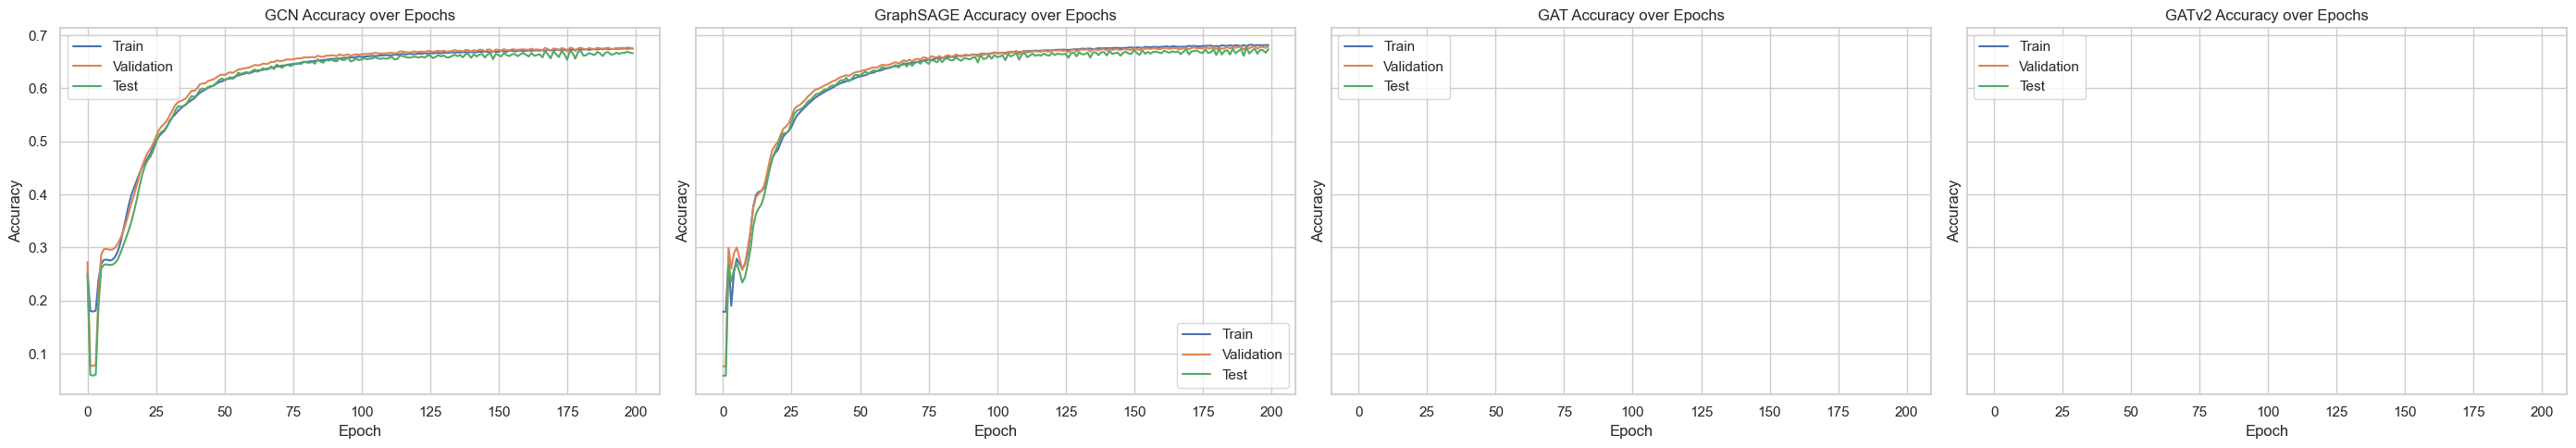

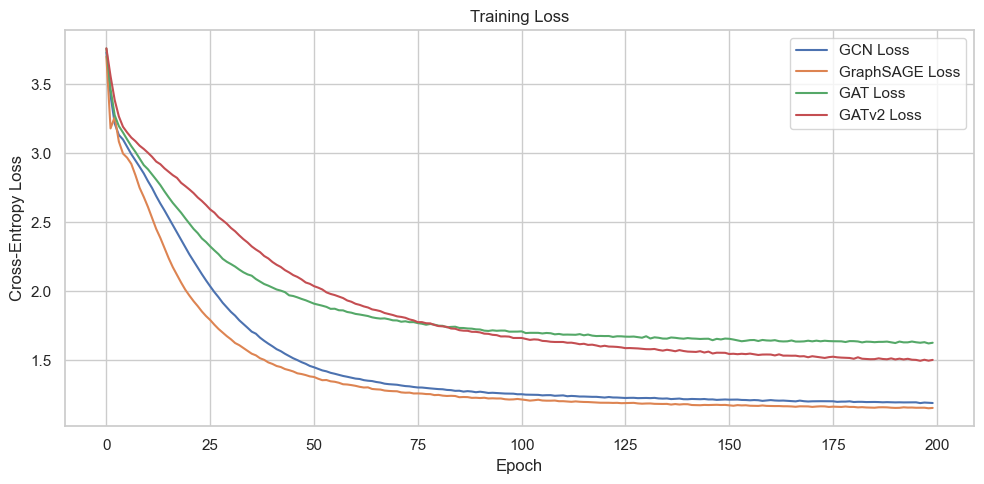

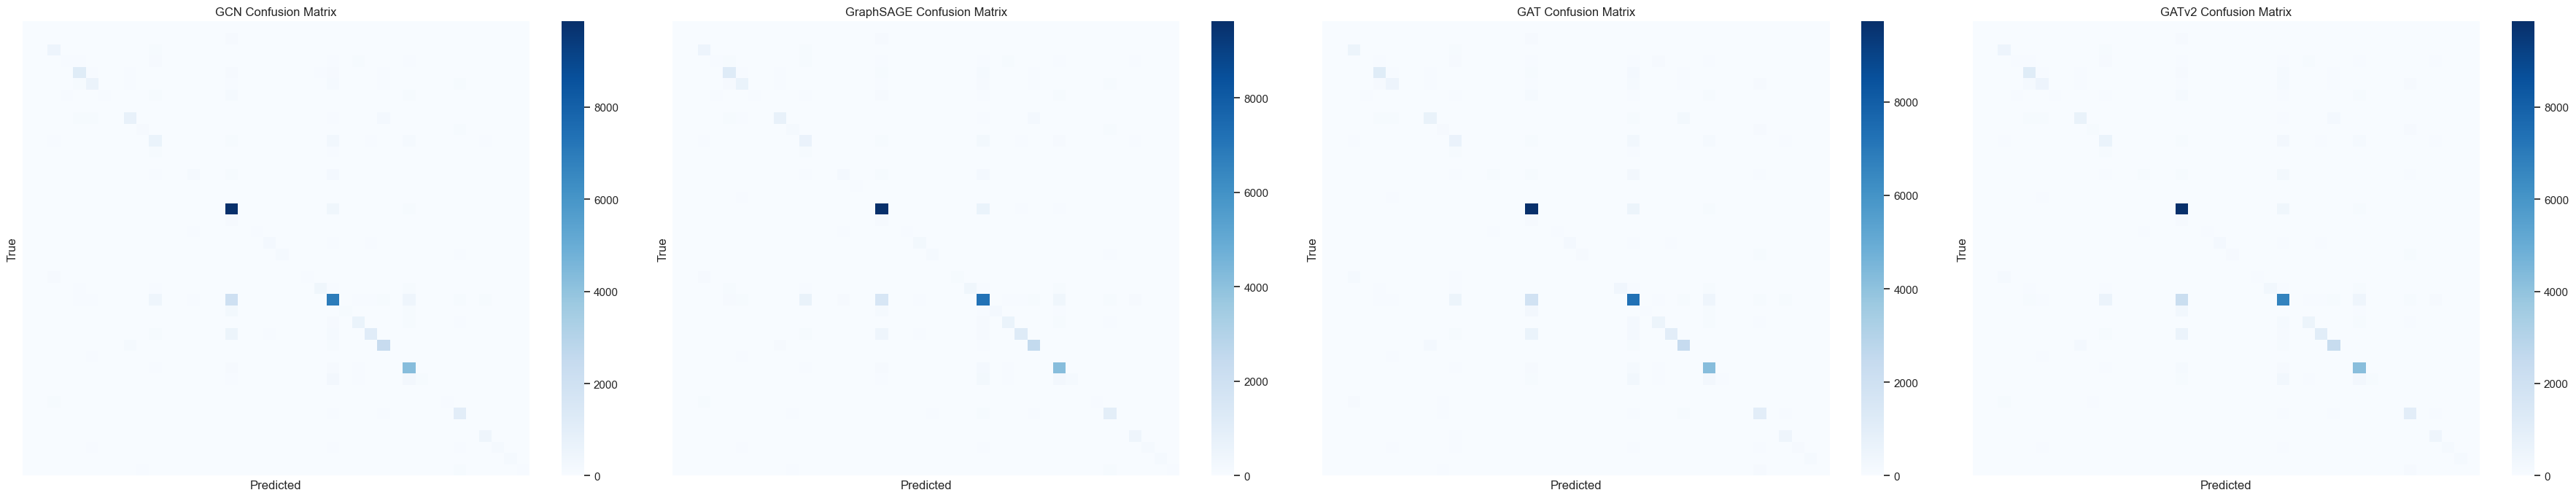

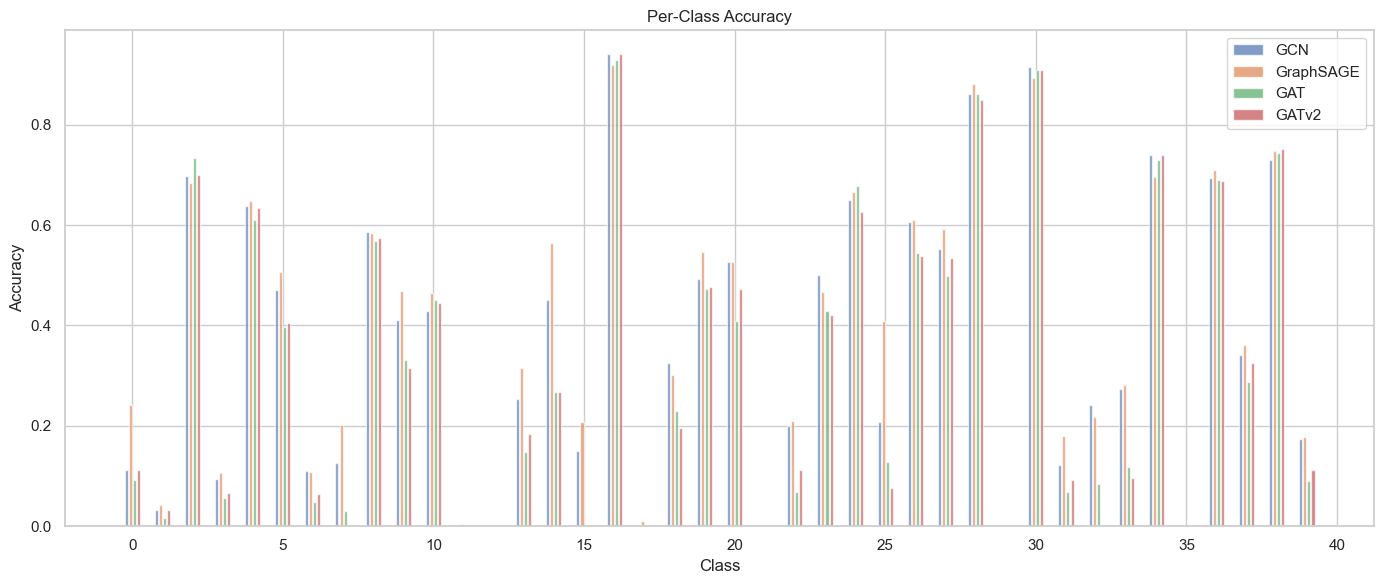

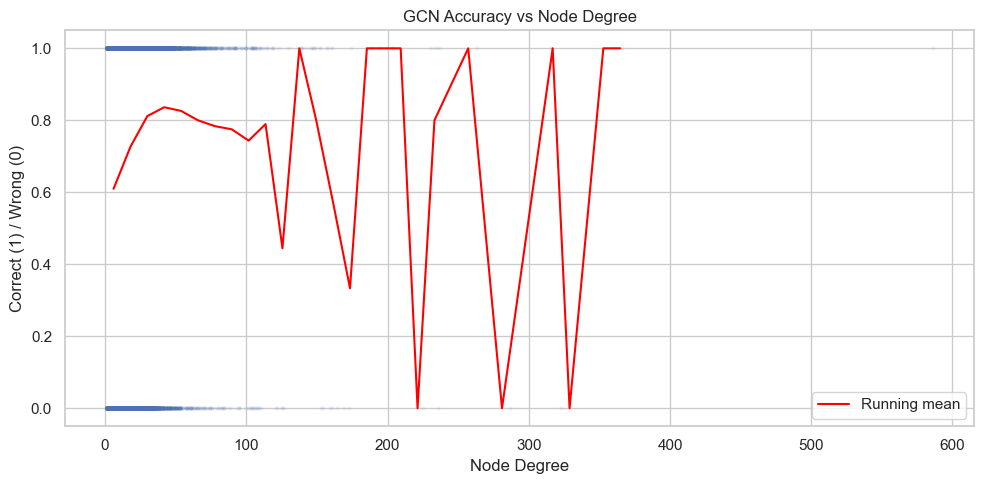

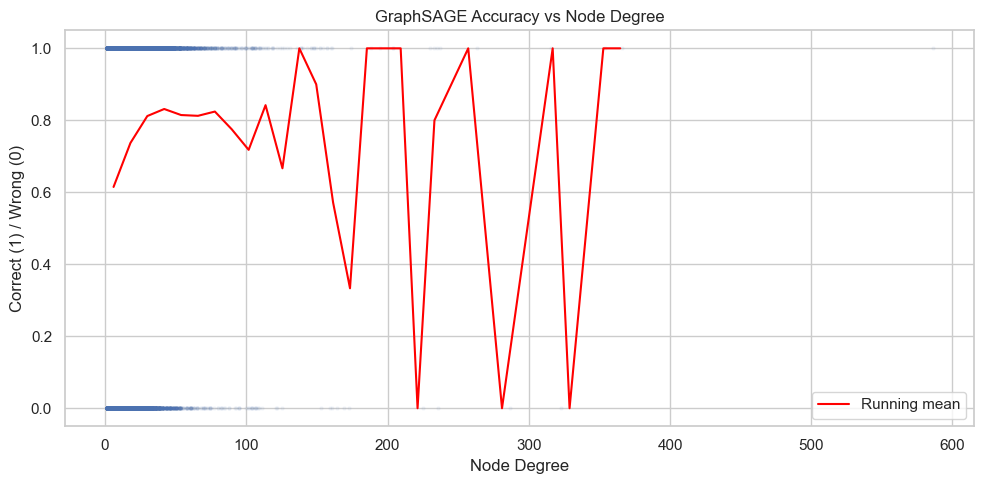

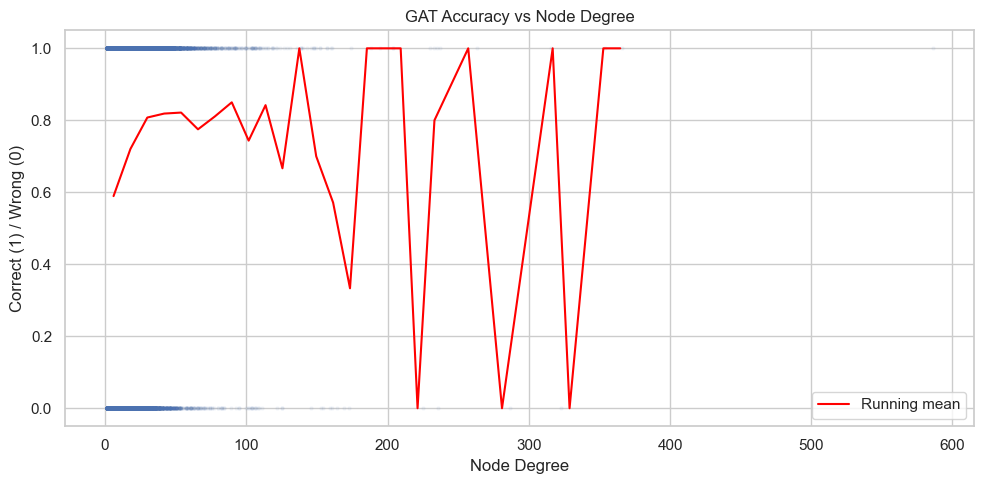

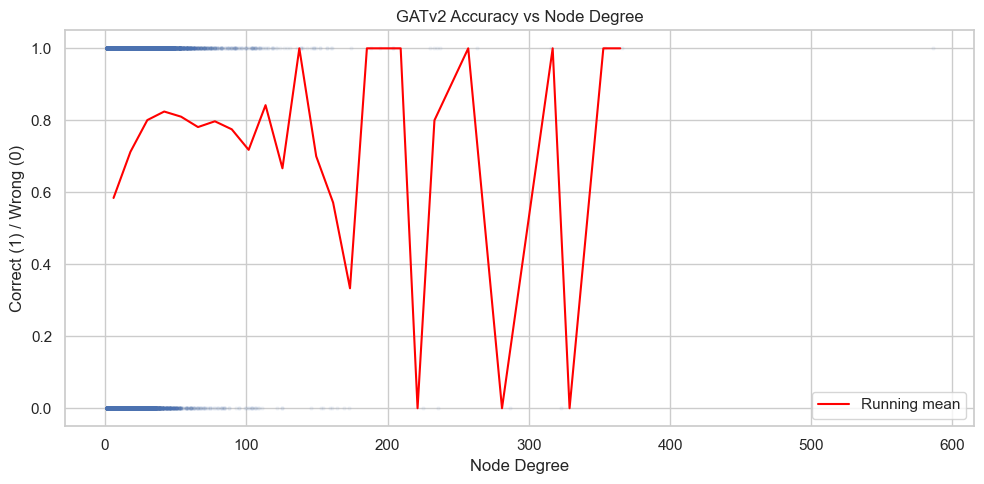

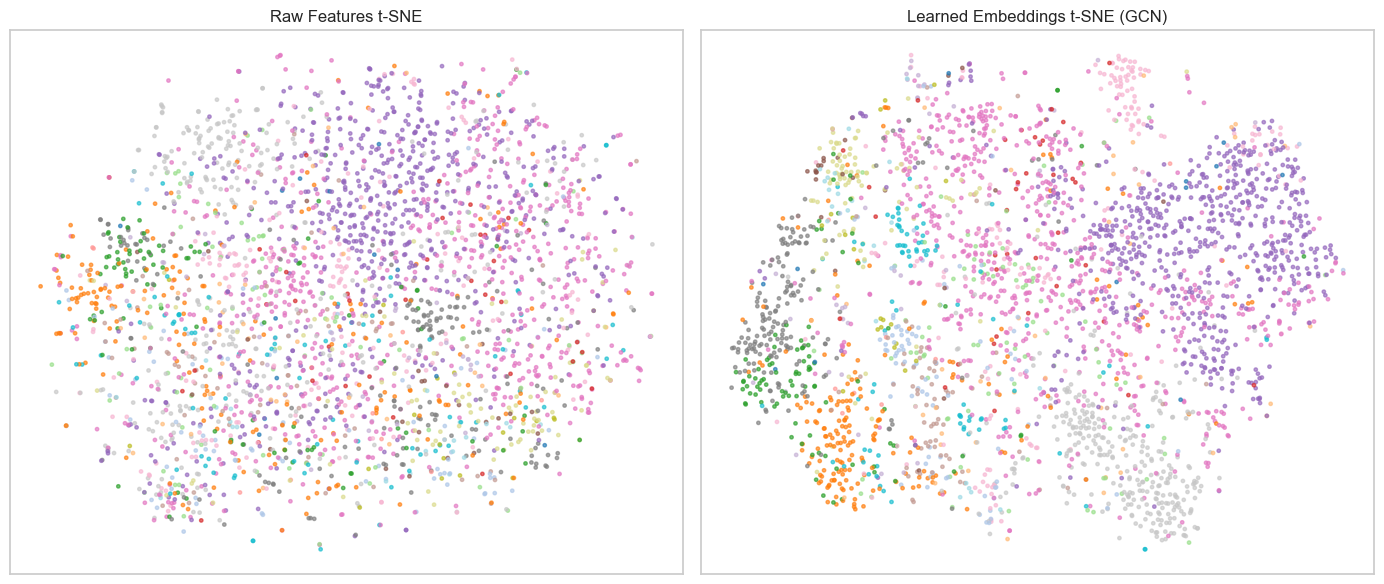

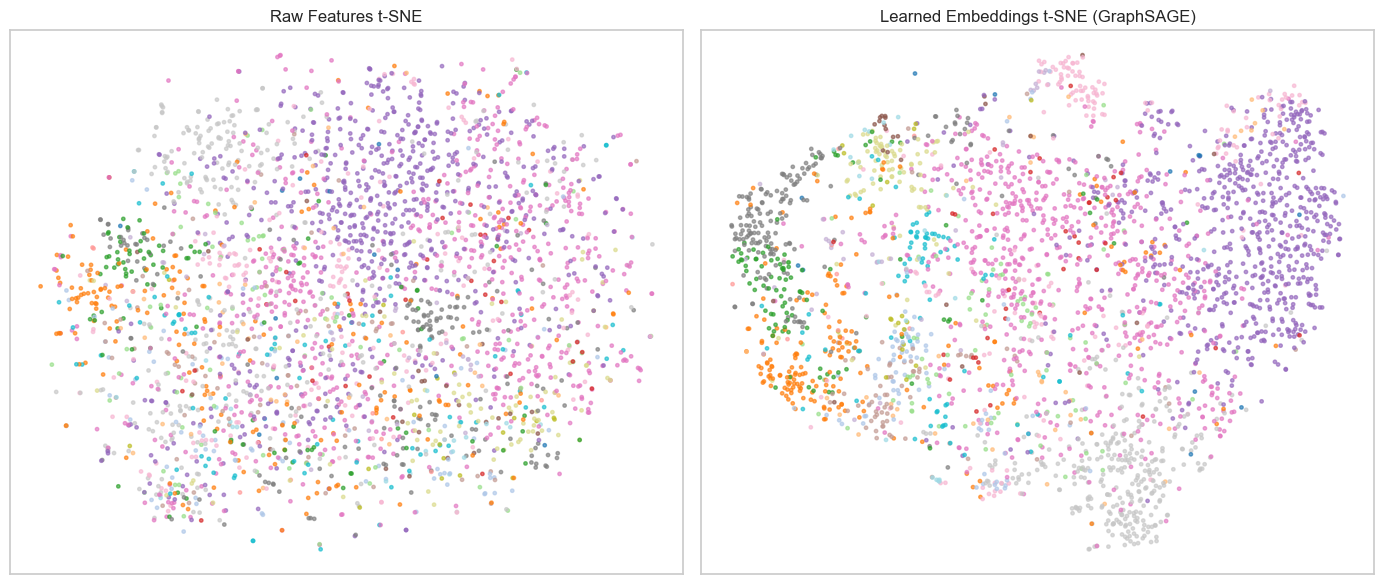

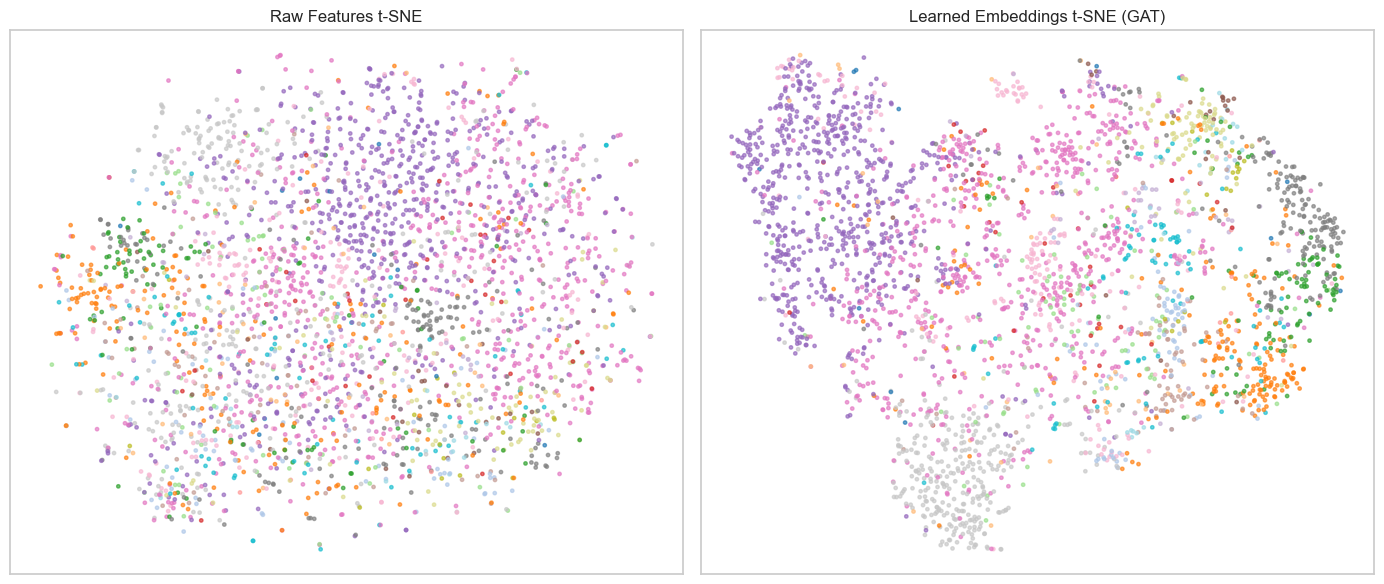

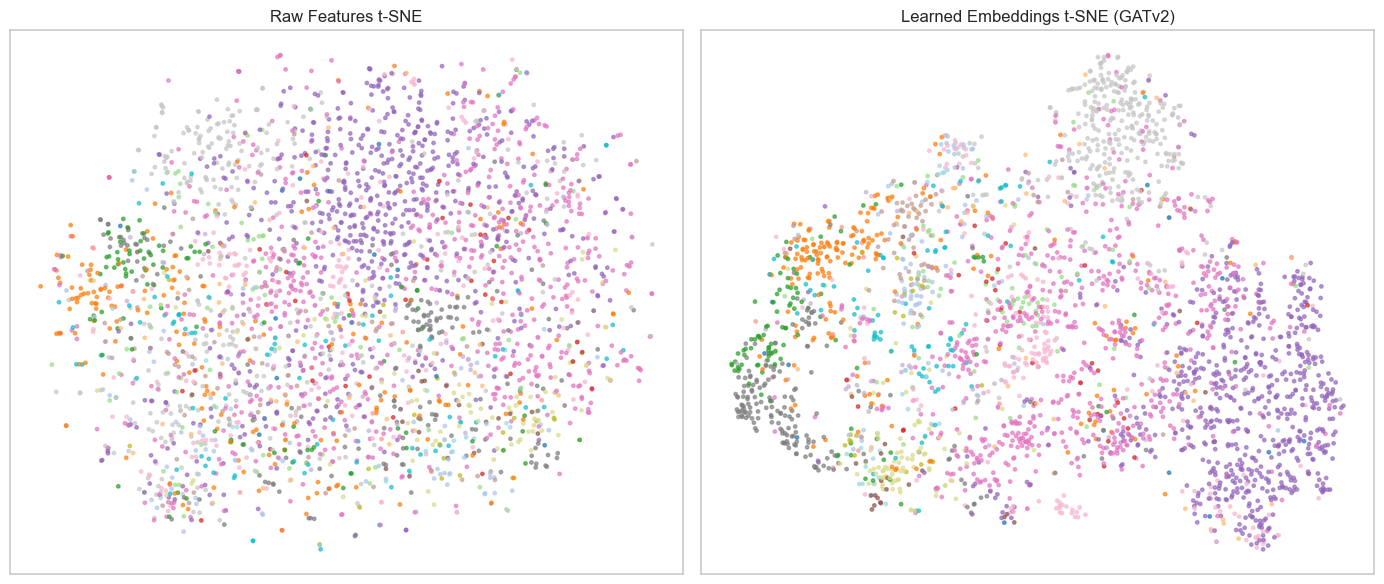

In [ ]:
ensure_results_loaded(load_models=False)

plot_training_curves(results)
plot_loss_curves(results)


test_index_cpu = split_idx['test'].detach().cpu()
y_true = data.y[test_index_cpu].view(-1).cpu().numpy()
predictions = {
    name: result['pred'][test_index_cpu].view(-1).numpy()
    for name, result in results.items()
}

plot_confusion_matrices(y_true, predictions)

per_class_scores = {
    name: compute_per_class_accuracy(y_true, pred, dataset.num_classes)
    for name, pred in predictions.items()
}
plot_per_class_accuracy(per_class_scores)

for name, pred in predictions.items():
    plot_degree_vs_accuracy(data, split_idx, pred, title=f'{name} Accuracy vs Node Degree')

global_edge_homophily = compute_edge_homophily(data)
candidate_node = int(split_idx['test'][0].item())
local_homophily_summary = plot_label_homophily_subgraph(
    data,
    node_idx=candidate_node,
    num_hops=1,
    max_nodes=20,
    title=f'Label-colored 1-hop subgraph around node {candidate_node}',
)
print(f'Global edge homophily: {global_edge_homophily:.4f}')
print(
    f"Local edge homophily around node {candidate_node}: "
    f"{local_homophily_summary['local_edge_homophily']:.4f}"
)

embedding_model_names = ['GCN', 'GraphSAGE', 'GAT', 'GATv2']
embeddings_by_model = collect_model_embeddings(embedding_model_names, data)
for model_name, embeddings in embeddings_by_model.items():
    plot_tsne_comparison(
        raw_features=data.x[test_index_cpu],
        learned_embeddings=embeddings[test_index_cpu],
        labels=data.y[test_index_cpu],
        sample_size=3000,
        perplexity=40,
        title_suffix=f' ({model_name})',
    )

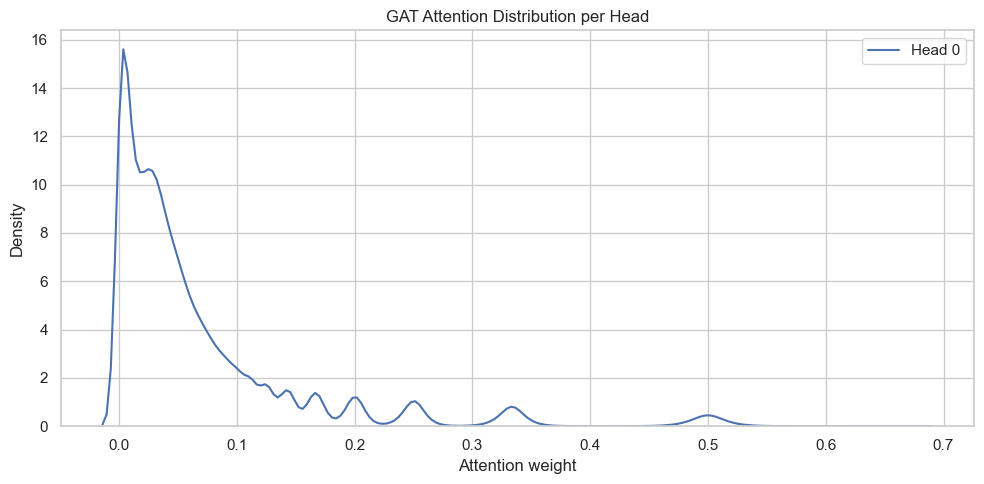

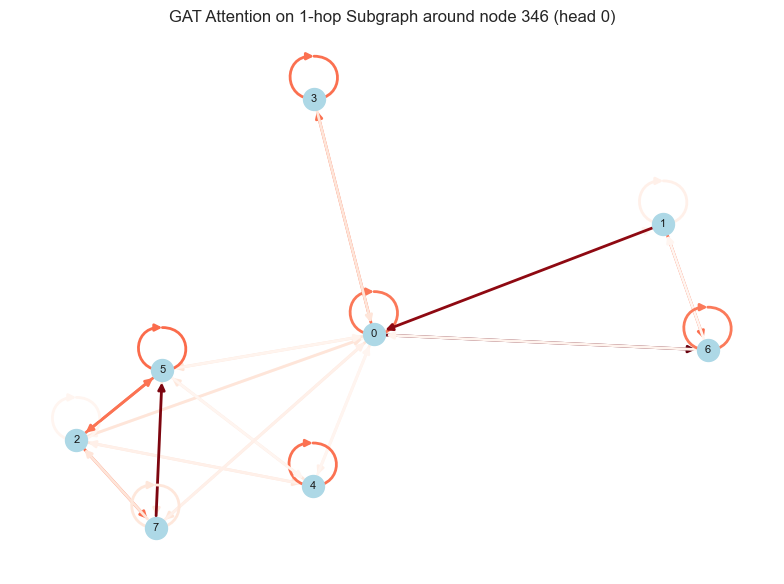

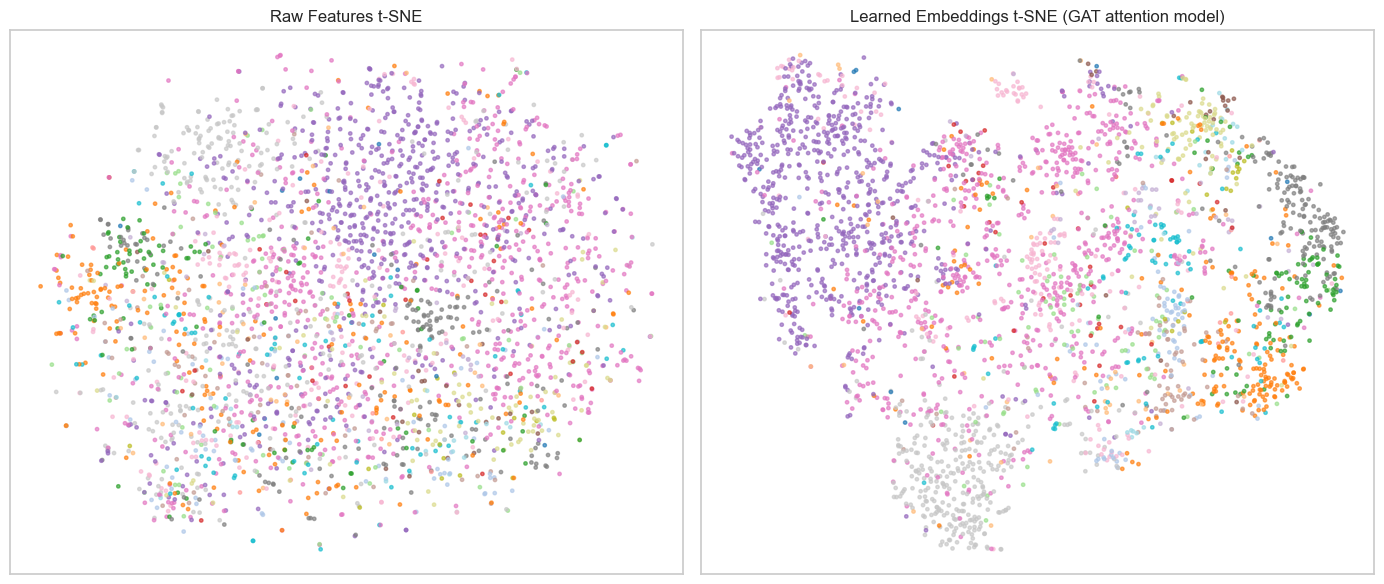

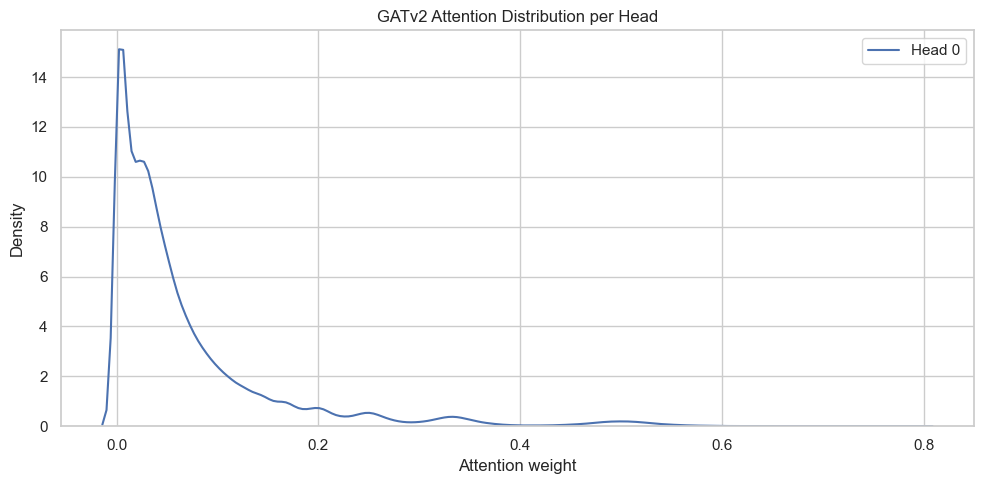

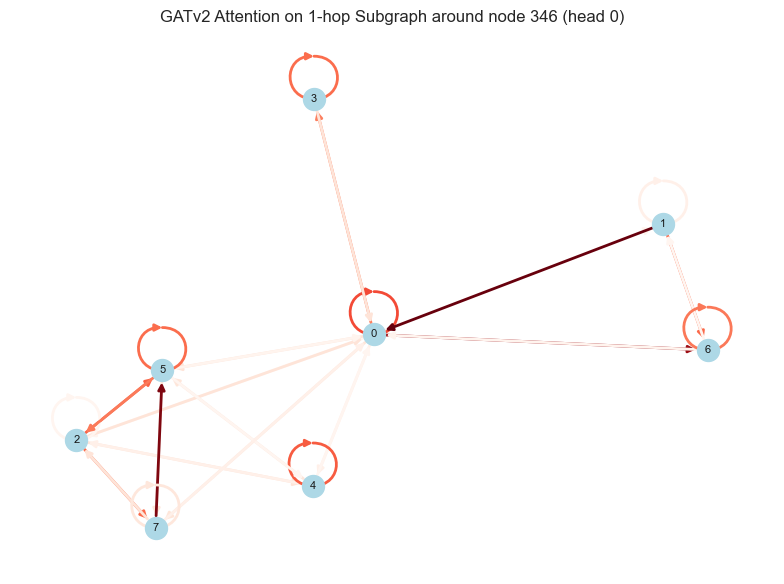

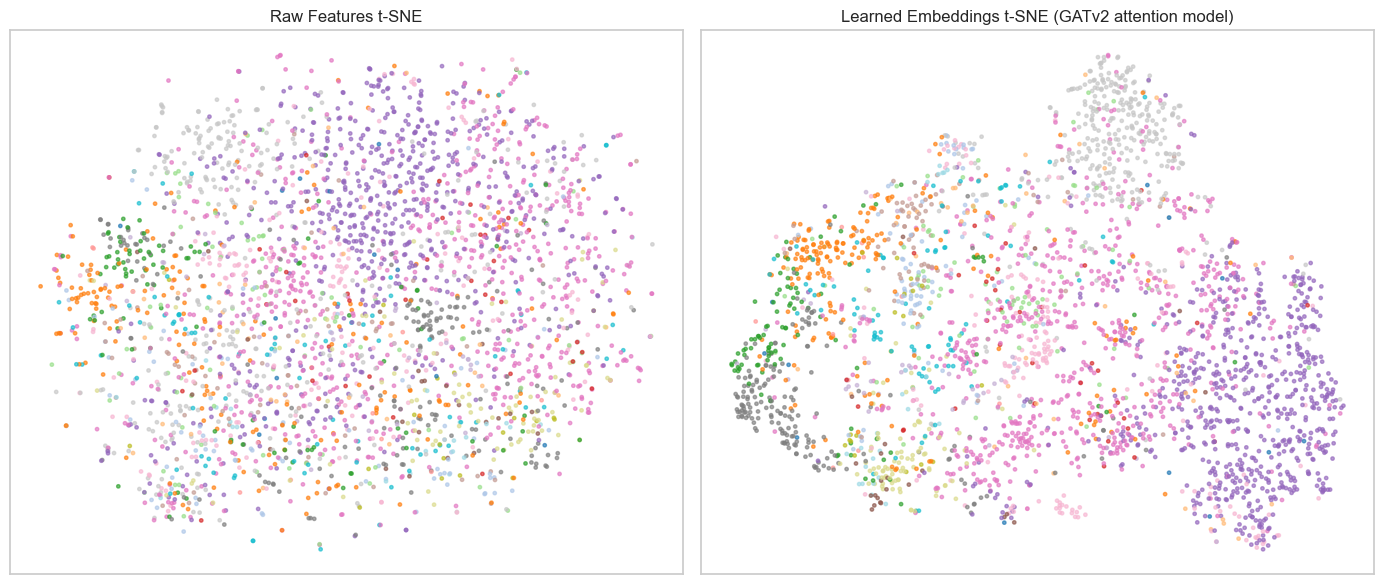

In [12]:
attention_model_names = ['GAT', 'GATv2']
ensure_results_loaded(load_models=True, model_names=attention_model_names)

candidate_node = int(split_idx['test'][0].item())

for model_name in attention_model_names:
    if model_name not in results or results[model_name].get('model') is None:
        continue

    model_embeddings, (edge_index_att, alpha) = export_attention(results[model_name]['model'], data)
    plot_attention_distribution(alpha, title=f'{model_name} Attention Distribution per Head')
    plot_attention_subgraph(
        edge_index_att,
        alpha,
        node_idx=candidate_node,
        num_hops=1,
        head_idx=0,
        title=f'{model_name} Attention on 1-hop Subgraph around node {candidate_node} (head 0)',
    )
    plot_tsne_comparison(
        raw_features=data.x[test_index_cpu],
        learned_embeddings=model_embeddings[test_index_cpu],
        labels=data.y[test_index_cpu],
        sample_size=3000,
        perplexity=40,
        title_suffix=f' ({model_name} attention model)',
    )

## 7. Next Steps

After the core comparison is complete, the natural extensions are:

1. Tune `NeighborLoader` batch sizes and neighborhood sizes for the attention models.
2. Compare the sampled `GATv2` setting against a larger configuration or a CPU-only full-batch reference.
3. Move to `GraphSAINT` or `ClusterLoader` if the sampled attention models are still too slow for the available hardware.